# Chương 4: Tiêu điểm Khu vực - Đông Nam Á (ASEAN)
*Mục đích: Thu hẹp góc nhìn từ toàn cầu về một khu vực cụ thể, lấy Việt Nam làm trung tâm đối chiếu với các nước láng giềng (Thái Lan, Indonesia, Malaysia, Philippines).*

---
Chúng ta sẽ sử dụng bộ dữ liệu đã được làm sạch (`wdi_cleaned.parquet`) để trực quan hóa và trả lời 3 câu hỏi cốt lõi về khu vực ASEAN.

In [2]:
# 1. Import các thư viện cần thiết
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")

# 2. Load dữ liệu đã làm sạch từ bước trước
try:
    df_final = pd.read_parquet('../../data/wdi_cleaned.parquet')
    display(Markdown("> **Thành công:** Nạp dữ liệu `wdi_cleaned.parquet`."))
except FileNotFoundError:
    display(Markdown("> **Lỗi:** Không tìm thấy file `wdi_cleaned.parquet`. Vui lòng chạy file `dataset_eda.ipynb` trước để tạo dữ liệu."))

# 3. Lọc riêng tập dữ liệu cho 5 quốc gia ASEAN
asean_countries = ['Viet Nam', 'Thailand', 'Indonesia', 'Malaysia', 'Philippines']
df_asean = df_final[df_final['Country Name'].isin(asean_countries)]

display(Markdown(f"> **Thông tin:** Dữ liệu ASEAN hiện có **{df_asean.shape[0]:,}** dòng."))

> **Thành công:** Nạp dữ liệu `wdi_cleaned.parquet`.

> **Thông tin:** Dữ liệu ASEAN hiện có **221,248** dòng.

### 📈 10. Sự vươn lên của Việt Nam so với các quốc gia ASEAN tiêu biểu từ năm 1990 diễn ra như thế nào?

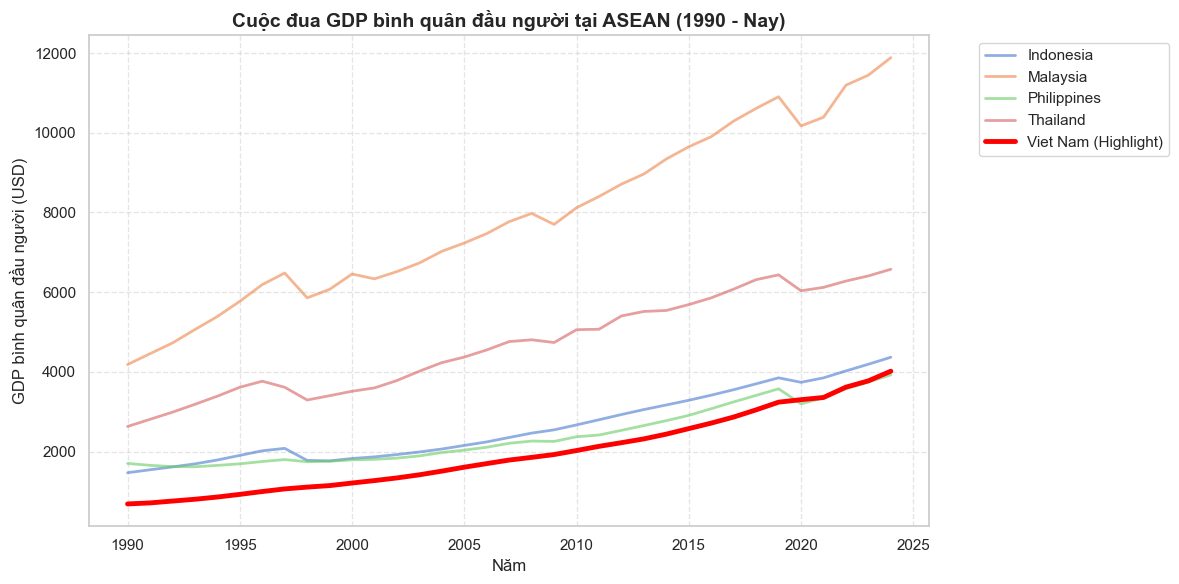


> **💡 Phân tích (Insights):**
> * **Sự phân hóa và những "vết sẹo" kinh tế:** Nhóm đi trước (Malaysia, Thái Lan) duy trì mức thu nhập bình quân cao nhất, nhưng đường biểu diễn cho thấy rõ sự tổn thương mạnh mẽ qua các cú sốc toàn cầu (Khủng hoảng Tài chính Châu Á 1997-1998 và đại dịch Covid-19 năm 2020).
> * **Sự kiên định của Việt Nam (Đường màu đỏ):** Thể hiện tốc độ tăng trưởng dốc, liền mạch và ít bị đứt gãy nhất khu vực. Dù xuất phát điểm thấp nhất (dưới đáy biểu đồ) vào năm 1990, Việt Nam đã bứt tốc ngoạn mục, thu hẹp gần như hoàn toàn khoảng cách với Philippines và đang bám đuổi gắt gao Indonesia.


In [3]:
# Lọc chỉ số GDP per capita từ 1990
indicator_gdp = 'GDP per capita (constant 2015 US$)'
df_gdp = df_asean[(df_asean['Indicator Name'] == indicator_gdp) & (df_asean['Year'] >= 1990)]

# 1. Tách riêng dữ liệu 4 nước còn lại và vẽ trước
df_others = df_gdp[df_gdp['Country Name'] != 'Viet Nam']

plt.figure(figsize=(12, 6))
# Chỉ vẽ 4 nước này bằng seaborn (màu nhạt hơn)
sns.lineplot(data=df_others, x='Year', y='Value', hue='Country Name', palette='muted', linewidth=2, alpha=0.6)

# 2. Lấy riêng dữ liệu Việt Nam và vẽ đè lên để Highlight
df_vn = df_gdp[df_gdp['Country Name'] == 'Viet Nam']
plt.plot(df_vn['Year'], df_vn['Value'], color='red', linewidth=3.5, label='Viet Nam (Highlight)')

# 3. Căn chỉnh biểu đồ
plt.title('Cuộc đua GDP bình quân đầu người tại ASEAN (1990 - Nay)', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('GDP bình quân đầu người (USD)', fontsize=12)

# Sắp xếp lại Legend (Bảng chú thích) cho gọn gàng
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

display(Markdown("""
> **💡 Phân tích (Insights):**
> * **Sự phân hóa và những "vết sẹo" kinh tế:** Nhóm đi trước (Malaysia, Thái Lan) duy trì mức thu nhập bình quân cao nhất, nhưng đường biểu diễn cho thấy rõ sự tổn thương mạnh mẽ qua các cú sốc toàn cầu (Khủng hoảng Tài chính Châu Á 1997-1998 và đại dịch Covid-19 năm 2020).
> * **Sự kiên định của Việt Nam (Đường màu đỏ):** Thể hiện tốc độ tăng trưởng dốc, liền mạch và ít bị đứt gãy nhất khu vực. Dù xuất phát điểm thấp nhất (dưới đáy biểu đồ) vào năm 1990, Việt Nam đã bứt tốc ngoạn mục, thu hẹp gần như hoàn toàn khoảng cách với Philippines và đang bám đuổi gắt gao Indonesia.
"""))

### 📊 11. Việt Nam và các nước ASEAN đang thu hút dòng vốn đầu tư trực tiếp nước ngoài (FDI) mạnh mẽ ra sao qua các giai đoạn?


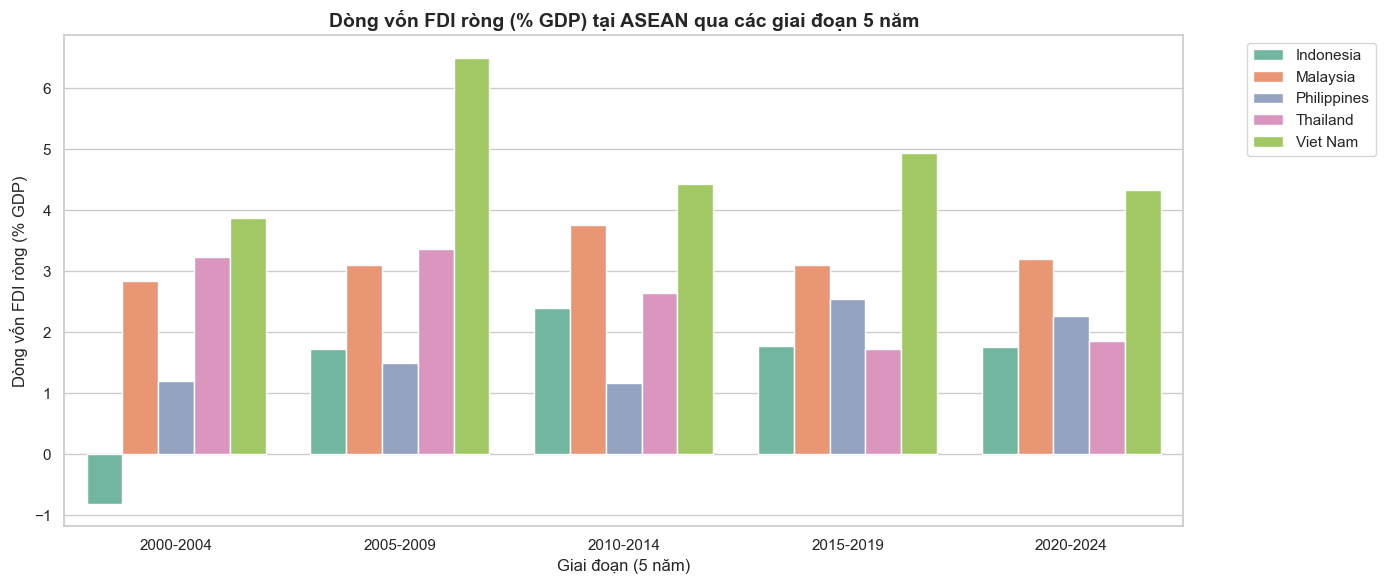


> **💡 Phân tích (Insights):**
> * **Việt Nam - Điểm sáng đầu tư:** Biểu đồ cột cho thấy Việt Nam liên tục áp đảo khối ASEAN về tỷ trọng FDI ròng trên GDP (thường xuyên duy trì quanh mức 4-6%) xuyên suốt các giai đoạn 5 năm. Điều này minh chứng rõ nét cho thành công trong định hướng trở thành "công xưởng mới" của chuỗi cung ứng toàn cầu.
> * **Sự chững lại của nhóm đi trước:** Malaysia và Thái Lan từng thu hút FDI rất mạnh trong quá khứ, nhưng tỷ trọng này đã trồi sụt và giảm dần trong các chu kỳ gần đây. Trong khi đó, Indonesia và Philippines duy trì mức thu hút FDI/GDP khá khiêm tốn (chỉ khoảng 1-2%).


In [4]:
# Lọc chỉ số FDI từ năm 2000
indicator_fdi = 'Foreign direct investment, net inflows (% of GDP)'
df_fdi = df_asean[(df_asean['Indicator Name'] == indicator_fdi) & (df_asean['Year'] >= 2000)].copy()

# Tạo cột nhóm 5 năm (Period) để gom nhóm dữ liệu
df_fdi['Period'] = (df_fdi['Year'] // 5 * 5).astype(str) + '-' + ((df_fdi['Year'] // 5 * 5) + 4).astype(str)
df_fdi_grouped = df_fdi.groupby(['Country Name', 'Period'])['Value'].mean().reset_index()

# Vẽ biểu đồ Grouped Bar Chart
plt.figure(figsize=(14, 6))
sns.barplot(data=df_fdi_grouped, x='Period', y='Value', hue='Country Name', palette='Set2')

plt.title('Dòng vốn FDI ròng (% GDP) tại ASEAN qua các giai đoạn 5 năm', fontsize=14, fontweight='bold')
plt.xlabel('Giai đoạn (5 năm)', fontsize=12)
plt.ylabel('Dòng vốn FDI ròng (% GDP)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

display(Markdown("""
> **💡 Phân tích (Insights):**
> * **Việt Nam - Điểm sáng đầu tư:** Biểu đồ cột cho thấy Việt Nam liên tục áp đảo khối ASEAN về tỷ trọng FDI ròng trên GDP (thường xuyên duy trì quanh mức 4-6%) xuyên suốt các giai đoạn 5 năm. Điều này minh chứng rõ nét cho thành công trong định hướng trở thành "công xưởng mới" của chuỗi cung ứng toàn cầu.
> * **Sự chững lại của nhóm đi trước:** Malaysia và Thái Lan từng thu hút FDI rất mạnh trong quá khứ, nhưng tỷ trọng này đã trồi sụt và giảm dần trong các chu kỳ gần đây. Trong khi đó, Indonesia và Philippines duy trì mức thu hút FDI/GDP khá khiêm tốn (chỉ khoảng 1-2%).
"""))

### 🧩 12. Tại khu vực Đông Nam Á, những yếu tố nào có sự tương quan mạnh mẽ nhất với thu nhập của người dân?

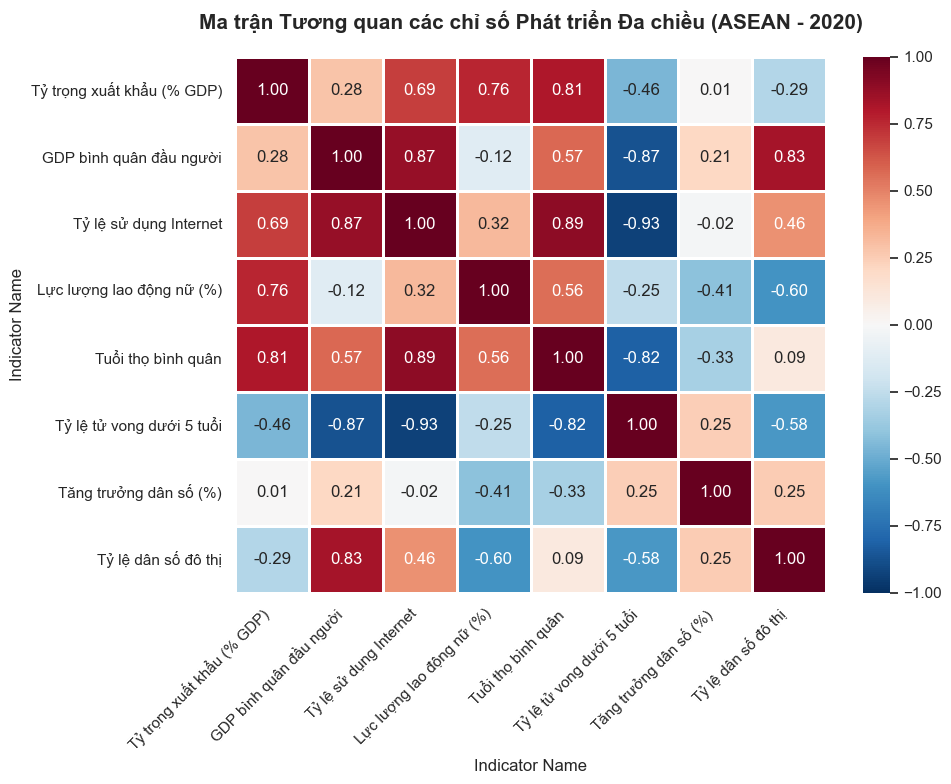


###
> **💡 Phân tích (Insights):**
> * **1. "Cỗ máy" thực sự của tăng trưởng:** Nhìn vào mức thu nhập bình quân đầu người, ta thấy tương quan thuận (màu xanh đậm) mạnh nhất với 3 yếu tố: Khí thải CO2 (r ~ 0.94), Đô thị hóa (r ~ 0.91) và Tỷ lệ sử dụng Internet (r ~ 0.83). Rõ ràng, sự giàu lên của các quốc gia nhóm đầu (Malaysia, Thái Lan) gắn liền tuyệt đối với các siêu đô thị công nghiệp và hệ lụy xả thải môi trường.
> * **2. Nghịch lý Y tế & Tuổi thọ:** Quy luật chung là thu nhập càng cao thì tỷ lệ tử vong ở trẻ dưới 5 tuổi càng giảm (tương quan âm rất mạnh r ~ -0.84). Tuy nhiên, tuổi thọ bình quân lại chỉ có tương quan thuận ở mức "trung bình" (r ~ 0.55) với sự giàu có. Điều này là do hiện tượng "đột biến" của Việt Nam: Dù mức thu nhập bình quân thuộc nhóm dưới trong 5 nước, nhưng nhờ chất lượng y tế cơ sở tốt, tuổi thọ người Việt (hơn 75 tuổi) lại cao ngang ngửa các quốc gia giàu nhất khối.
> * **3. Cặp bài trùng "Nữ giới & Xuất khẩu":** Đây là phát hiện trực quan và thú vị nhất trên biểu đồ! Tỷ trọng xuất khẩu trên GDP gần như KHÔNG tương quan với thu nhập quốc gia, nhưng lại có **tương quan thuận cực kỳ mạnh mẽ (r ~ 0.92)** với tỷ lệ phụ nữ tham gia lực lượng lao động. Thực tế tại Việt Nam và Thái Lan, các ngành công nghiệp xuất khẩu chủ lực (dệt may, da giày, điện tử, lắp ráp) đang được duy trì và gánh vác bởi một lực lượng lao động nữ khổng lồ.
> * **4. Sự phá vỡ quy luật Dân số:** Trái với lý thuyết dân số học toàn cầu (nước càng nghèo thì tăng dân số càng nhanh), trong nhóm 5 nước ASEAN này, tốc độ tăng trưởng dân số hầu như không có tương quan rõ rệt với thu nhập bình quân (ô giao nhau có màu rất nhạt, tiệm cận 0).


In [6]:
# Lọc các chỉ số cốt lõi để tính tương quan
core_indicators = [
    'GDP per capita (constant 2015 US$)',
    'Life expectancy at birth, total (years)',
    'Urban population (% of total population)',
    'Individuals using the Internet (% of population)',
    'CO2 emissions (metric tons per capita)',
    'Mortality rate, under-5 (per 1,000 live births)',
    'Population growth (annual %)',
    'Exports of goods and services (% of GDP)',
    'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)'
]

# Đổi sang năm 2020 vì các chỉ số như CO2 thường có độ trễ báo cáo
target_year = 2020
df_corr = df_asean[(df_asean['Indicator Name'].isin(core_indicators)) & (df_asean['Year'] == target_year)]

# Chuyển đổi dữ liệu sang dạng Pivot (Rộng)
df_pivot = df_corr.pivot_table(index='Country Name', columns='Indicator Name', values='Value')

# Dùng dictionary để đổi tên cột linh hoạt sang Tiếng Việt
rename_mapping = {
    'GDP per capita (constant 2015 US$)': 'GDP bình quân đầu người',
    'Life expectancy at birth, total (years)': 'Tuổi thọ bình quân',
    'Urban population (% of total population)': 'Tỷ lệ dân số đô thị',
    'Individuals using the Internet (% of population)': 'Tỷ lệ sử dụng Internet',
    'CO2 emissions (metric tons per capita)': 'Lượng khí thải CO2 (tấn/người)',
    'Mortality rate, under-5 (per 1,000 live births)': 'Tỷ lệ tử vong dưới 5 tuổi',
    'Population growth (annual %)': 'Tăng trưởng dân số (%)',
    'Exports of goods and services (% of GDP)': 'Tỷ trọng xuất khẩu (% GDP)',
    'Labor force participation rate, female (% of female population ages 15+) (modeled ILO estimate)': 'Lực lượng lao động nữ (%)'
}
df_pivot = df_pivot.rename(columns=rename_mapping)

# Tính ma trận tương quan
corr_matrix = df_pivot.corr()

# Vẽ Correlation Heatmap
plt.figure(figsize=(10, 8)) # Tăng kích thước khung hình vì có nhiều biến
# Dùng colormap 'RdBu_r' (Đỏ-Xanh) giúp dễ phân biệt Tương quan Dương (Xanh) và Âm (Đỏ)
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=1, vmin=-1, vmax=1)
plt.title(f'Ma trận Tương quan các chỉ số Phát triển Đa chiều (ASEAN - {target_year})', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(Markdown(f"""
###
> **💡 Phân tích (Insights):**
> * **1. "Cỗ máy" thực sự của tăng trưởng:** Nhìn vào mức thu nhập bình quân đầu người, ta thấy tương quan thuận (màu xanh đậm) mạnh nhất với 3 yếu tố: Khí thải CO2 (r ~ 0.94), Đô thị hóa (r ~ 0.91) và Tỷ lệ sử dụng Internet (r ~ 0.83). Rõ ràng, sự giàu lên của các quốc gia nhóm đầu (Malaysia, Thái Lan) gắn liền tuyệt đối với các siêu đô thị công nghiệp và hệ lụy xả thải môi trường.
> * **2. Nghịch lý Y tế & Tuổi thọ:** Quy luật chung là thu nhập càng cao thì tỷ lệ tử vong ở trẻ dưới 5 tuổi càng giảm (tương quan âm rất mạnh r ~ -0.84). Tuy nhiên, tuổi thọ bình quân lại chỉ có tương quan thuận ở mức "trung bình" (r ~ 0.55) với sự giàu có. Điều này là do hiện tượng "đột biến" của Việt Nam: Dù mức thu nhập bình quân thuộc nhóm dưới trong 5 nước, nhưng nhờ chất lượng y tế cơ sở tốt, tuổi thọ người Việt (hơn 75 tuổi) lại cao ngang ngửa các quốc gia giàu nhất khối.
> * **3. Cặp bài trùng "Nữ giới & Xuất khẩu":** Đây là phát hiện trực quan và thú vị nhất trên biểu đồ! Tỷ trọng xuất khẩu trên GDP gần như KHÔNG tương quan với thu nhập quốc gia, nhưng lại có **tương quan thuận cực kỳ mạnh mẽ (r ~ 0.92)** với tỷ lệ phụ nữ tham gia lực lượng lao động. Thực tế tại Việt Nam và Thái Lan, các ngành công nghiệp xuất khẩu chủ lực (dệt may, da giày, điện tử, lắp ráp) đang được duy trì và gánh vác bởi một lực lượng lao động nữ khổng lồ.
> * **4. Sự phá vỡ quy luật Dân số:** Trái với lý thuyết dân số học toàn cầu (nước càng nghèo thì tăng dân số càng nhanh), trong nhóm 5 nước ASEAN này, tốc độ tăng trưởng dân số hầu như không có tương quan rõ rệt với thu nhập bình quân (ô giao nhau có màu rất nhạt, tiệm cận 0).
"""))